# Resume Classification - Data Preprocessing

This notebook covers comprehensive data preprocessing for resume classification including:
- Data exploration and visualization
- Text cleaning and normalization
- Skill extraction using NLP
- SBERT embeddings generation
- Feature preparation for ML models

---

## 1. Import Required Libraries

Import all necessary libraries for data preprocessing, visualization, and NLP.

In [1]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')

# Text processing
import re
import string
from collections import Counter

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer

# SBERT for embeddings
from sentence_transformers import SentenceTransformer

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")


## 2. Load and Explore Dataset

Load the resume dataset and perform initial exploration to understand the data structure.

In [2]:
# Load the dataset
df = pd.read_csv('resume_dataset.csv')

print("Dataset Overview:")
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head()

Dataset Overview:
Shape: (169, 2)
Columns: ['Category', 'Resume']


,Category,Resume
0,Data Science,"Skills * Programming Languages: Python (pandas, numpy, scipy, scikit-learn, matplotlib), Sql, Ja..."
1,Data Science,Education Details \nMay 2013 to May 2017 B.E UIT-RGPVData ScientistData Scientist - MatelabsSk...
2,Data Science,"Areas of Interest Deep Learning, Control System Design, Programming in-Python, Electric Machiner..."
3,Data Science,Skills â¢ R â¢ Python â¢ SAP HANA â¢ Tableau â¢ SAP HANA SQL â¢ SAP HANA PAL â¢ MS SQL â...
4,Data Science,"Education Details \n MCA YMCAUST, Faridabad, HaryanaData Science internshipSkill Details \nD..."


In [3]:
# Basic information about the dataset
print("Dataset Info:")
df.info()
print("\n")
print("Statistical Summary:")
df.describe()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 169 entries, 0 to 168
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  169 non-null    object
 1   Resume    169 non-null    object
dtypes: object(2)
memory usage: 2.8+ KB


Statistical Summary:


,Category,Resume
count,169,169
unique,25,166
top,Java Developer,"Technical Skills Web Technologies: Angular JS, HTML5, CSS3, SASS, Bootstrap, Jquery, Javascript...."
freq,14,2


In [4]:
# Check unique categories
print("Job Categories:")
print(f"Total categories: {df['Category'].nunique()}")
print(f"Categories: {sorted(df['Category'].unique())}")

print("\n Category Distribution:")
category_counts = df['Category'].value_counts()
print(category_counts)

Job Categories:
Total categories: 25
Categories: ['Advocate', 'Arts', 'Automation Testing', 'Blockchain', 'Business Analyst', 'Civil Engineer', 'Data Science', 'Database', 'DevOps Engineer', 'DotNet Developer', 'ETL Developer', 'Electrical Engineering', 'HR', 'Hadoop', 'Health and fitness', 'Java Developer', 'Mechanical Engineer', 'Network Security Engineer', 'Operations Manager', 'PMO', 'Python Developer', 'SAP Developer', 'Sales', 'Testing', 'Web Designing']

 Category Distribution:
Category
Java Developer               14
Database                     11
HR                           11
Data Science                 10
Advocate                     10
Automation Testing            7
DevOps Engineer               7
Testing                       7
DotNet Developer              7
Hadoop                        7
SAP Developer                 6
Python Developer              6
Health and fitness            6
Civil Engineer                6
Arts                          6
Business Analyst     

## 3. Handle Missing Values

Check for and handle any missing values in the dataset.

In [5]:
# Check for missing values
print("Missing Values Check:")
missing_values = df.isnull().sum()
print(missing_values)

if missing_values.sum() == 0:
    print("No missing values found!")
else:
    print("Missing values detected!")
    
# Check for empty strings
print("\n Empty String Check:")
empty_resumes = df['Resume'].str.strip().eq('').sum()
print(f"Empty resumes: {empty_resumes}")

if empty_resumes > 0:
    print("Removing empty resumes...")
    df = df[df['Resume'].str.strip() != '']
    print(f"New shape: {df.shape}")

Missing Values Check:
Category    0
Resume      0
dtype: int64
No missing values found!

 Empty String Check:
Empty resumes: 0


## 4. Remove Duplicates

Detect and remove any duplicate resumes from the dataset.

In [6]:
# Check for duplicates
print("Duplicate Check:")
duplicates = df.duplicated().sum()
print(f"Total duplicates: {duplicates}")

# Check for duplicate resumes (same text)
resume_duplicates = df['Resume'].duplicated().sum()
print(f"Duplicate resumes: {resume_duplicates}")

if duplicates > 0:
    print("Removing duplicates...")
    df = df.drop_duplicates()
    print(f"New shape: {df.shape}")
else:
    print("No duplicates found!")

# Reset index
df = df.reset_index(drop=True)
print(f"Final dataset shape: {df.shape}")

Duplicate Check:
Total duplicates: 3
Duplicate resumes: 3
Removing duplicates...
New shape: (166, 2)
Final dataset shape: (166, 2)


## 5. Data Type Conversion and Text Analysis

Analyze text characteristics and prepare for processing.

In [7]:
# Text statistics
print("Text Statistics:")
df['text_length'] = df['Resume'].str.len()
df['word_count'] = df['Resume'].str.split().str.len()
df['sentence_count'] = df['Resume'].str.count(r'[.!?]') + 1

text_stats = {
    'Average text length': df['text_length'].mean(),
    'Average word count': df['word_count'].mean(),
    'Average sentence count': df['sentence_count'].mean(),
    'Min text length': df['text_length'].min(),
    'Max text length': df['text_length'].max()
}

for key, value in text_stats.items():
    print(f"{key}: {value:.2f}")

Text Statistics:
Average text length: 2935.42
Average word count: 422.23
Average sentence count: 25.26
Min text length: 129.00
Max text length: 14609.00


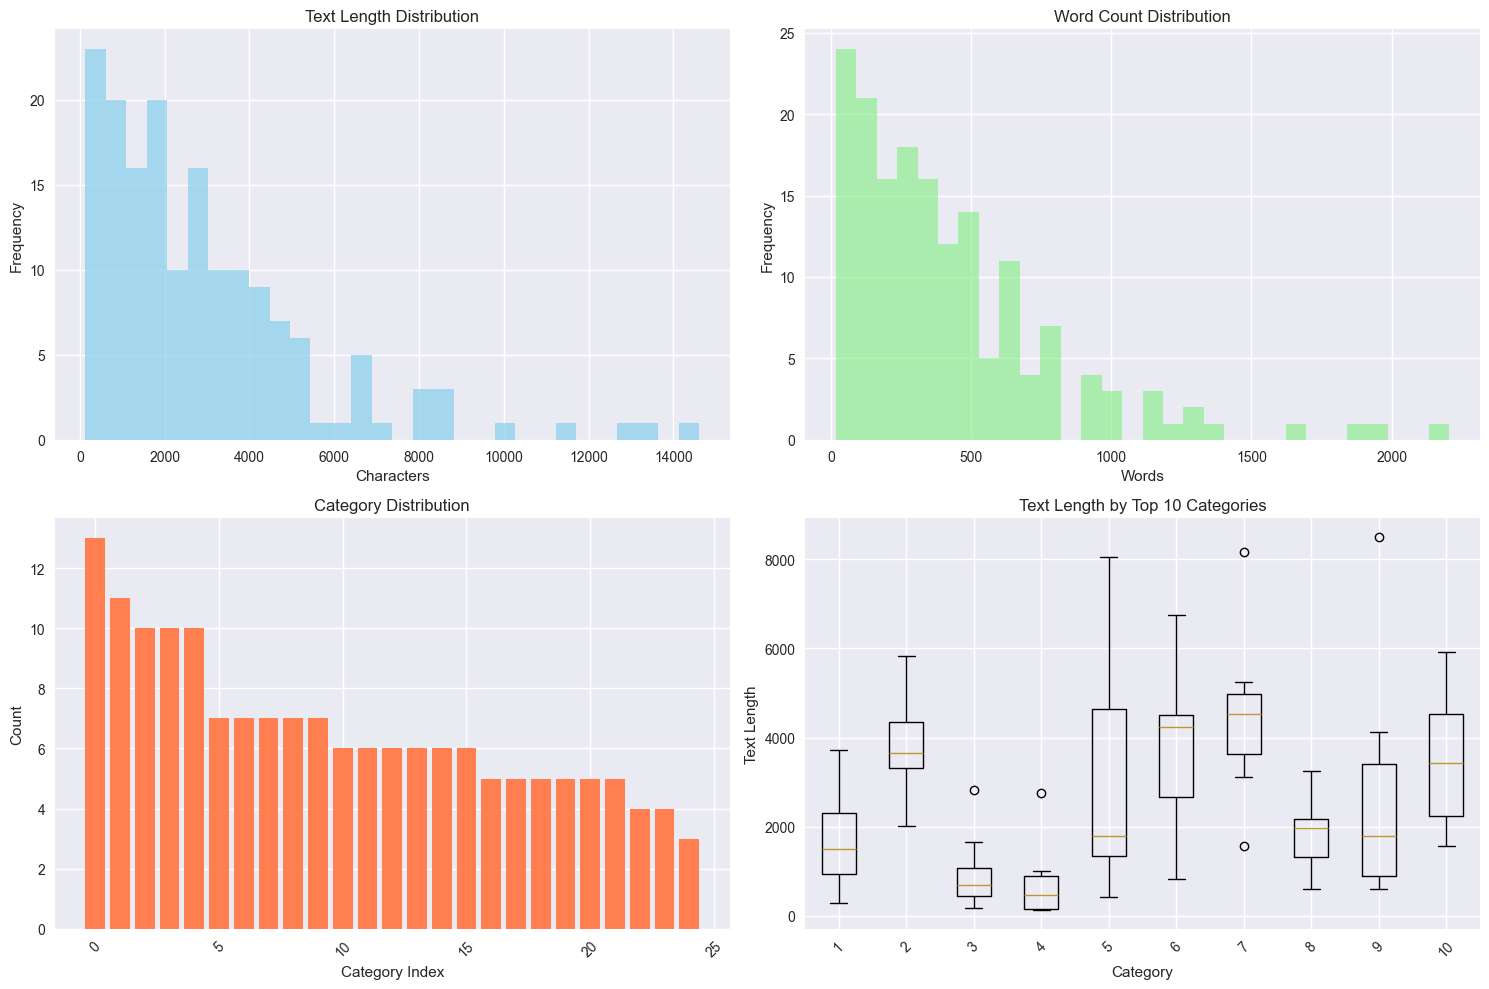

In [8]:
# Visualize text length distribution
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Text length distribution
axes[0, 0].hist(df['text_length'], bins=30, alpha=0.7, color='skyblue')
axes[0, 0].set_title('Text Length Distribution')
axes[0, 0].set_xlabel('Characters')
axes[0, 0].set_ylabel('Frequency')

# Word count distribution
axes[0, 1].hist(df['word_count'], bins=30, alpha=0.7, color='lightgreen')
axes[0, 1].set_title('Word Count Distribution')
axes[0, 1].set_xlabel('Words')
axes[0, 1].set_ylabel('Frequency')

# Category distribution
category_counts = df['Category'].value_counts()
axes[1, 0].bar(range(len(category_counts)), category_counts.values, color='coral')
axes[1, 0].set_title('Category Distribution')
axes[1, 0].set_xlabel('Category Index')
axes[1, 0].set_ylabel('Count')
axes[1, 0].tick_params(axis='x', rotation=45)

# Text length by category (boxplot)
# Get top 10 categories for better visualization
top_categories = category_counts.head(10).index
df_top = df[df['Category'].isin(top_categories)]
axes[1, 1].boxplot([df_top[df_top['Category'] == cat]['text_length'].values 
                   for cat in top_categories])
axes[1, 1].set_title('Text Length by Top 10 Categories')
axes[1, 1].set_xlabel('Category')
axes[1, 1].set_ylabel('Text Length')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 6. Text Preprocessing and Cleaning

Clean and normalize the resume text for better processing.

In [9]:
def clean_text(text):
    """Clean and preprocess resume text"""
    if pd.isna(text):
        return ""
    
    # Convert to string and lowercase
    text = str(text).lower()
    
    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    
    # Remove email addresses
    text = re.sub(r'\S+@\S+', '', text)
    
    # Remove phone numbers
    text = re.sub(r'\+?\d[\d\s\-\(\)]{7,}\d', '', text)
    
    # Remove special characters but keep important ones for skills
    text = re.sub(r'[^\w\s\+\#\-\.]', ' ', text)
    
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text)
    
    # Remove leading/trailing whitespace
    text = text.strip()
    
    return text

# Apply text cleaning
print("Cleaning text...")
df['Resume_cleaned'] = df['Resume'].apply(clean_text)

# Check cleaning results
print("\n Cleaning Results:")
print(f"Original avg length: {df['Resume'].str.len().mean():.2f}")
print(f"Cleaned avg length: {df['Resume_cleaned'].str.len().mean():.2f}")

# Show example
print("\n Example:")
print("Original:")
print(df['Resume'].iloc[0][:200] + "...")
print("\nCleaned:")
print(df['Resume_cleaned'].iloc[0][:200] + "...")

Cleaning text...

 Cleaning Results:
Original avg length: 2935.42
Cleaned avg length: 2826.99

 Example:
Original:
Skills * Programming Languages: Python (pandas, numpy, scipy, scikit-learn, matplotlib), Sql, Java, JavaScript/JQuery. * Machine learning: Regression, SVM, NaÃ¯ve Bayes, KNN, Random Forest, Decision T...

Cleaned:
skills programming languages python pandas numpy scipy scikit-learn matplotlib sql java javascript jquery. machine learning regression svm naã ve bayes knn random forest decision trees boosting techni...


## 7. Skill Extraction and Analysis

Extract technical skills and analyze their distribution across categories.

In [10]:
# Define common technical skills
TECHNICAL_SKILLS = {
    'programming': ['python', 'java', 'javascript', 'c++', 'c#', 'php', 'ruby', 'go', 'rust', 'scala', 'kotlin'],
    'web': ['html', 'css', 'react', 'angular', 'vue', 'node.js', 'express', 'django', 'flask', 'spring'],
    'database': ['sql', 'mysql', 'postgresql', 'mongodb', 'oracle', 'sqlite', 'redis', 'cassandra'],
    'cloud': ['aws', 'azure', 'gcp', 'docker', 'kubernetes', 'jenkins', 'terraform'],
    'data_science': ['pandas', 'numpy', 'scikit-learn', 'tensorflow', 'pytorch', 'keras', 'matplotlib', 'seaborn'],
    'tools': ['git', 'github', 'jira', 'confluence', 'slack', 'linux', 'windows', 'macos']
}

# Flatten all skills
ALL_SKILLS = []
for category, skills in TECHNICAL_SKILLS.items():
    ALL_SKILLS.extend(skills)

def extract_skills(text):
    """Extract technical skills from resume text"""
    if pd.isna(text):
        return []
    
    text = text.lower()
    found_skills = []
    
    for skill in ALL_SKILLS:
        if skill in text:
            found_skills.append(skill)
    
    return found_skills

# Extract skills
print("Extracting skills...")
df['skills'] = df['Resume_cleaned'].apply(extract_skills)
df['skill_count'] = df['skills'].apply(len)

print(f"Skills Statistics:")
print(f"Average skills per resume: {df['skill_count'].mean():.2f}")
print(f"Max skills in a resume: {df['skill_count'].max()}")
print(f"Resumes with no skills: {(df['skill_count'] == 0).sum()}")

Extracting skills...
Skills Statistics:
Average skills per resume: 4.10
Max skills in a resume: 19
Resumes with no skills: 28


Top 20 Skills:
go: 96
sql: 71
windows: 53
java: 51
html: 36
oracle: 33
mysql: 31
python: 29
javascript: 23
linux: 23
css: 22
git: 19
c++: 19
scala: 16
angular: 14
aws: 13
rust: 12
spring: 12
jira: 11
c#: 9


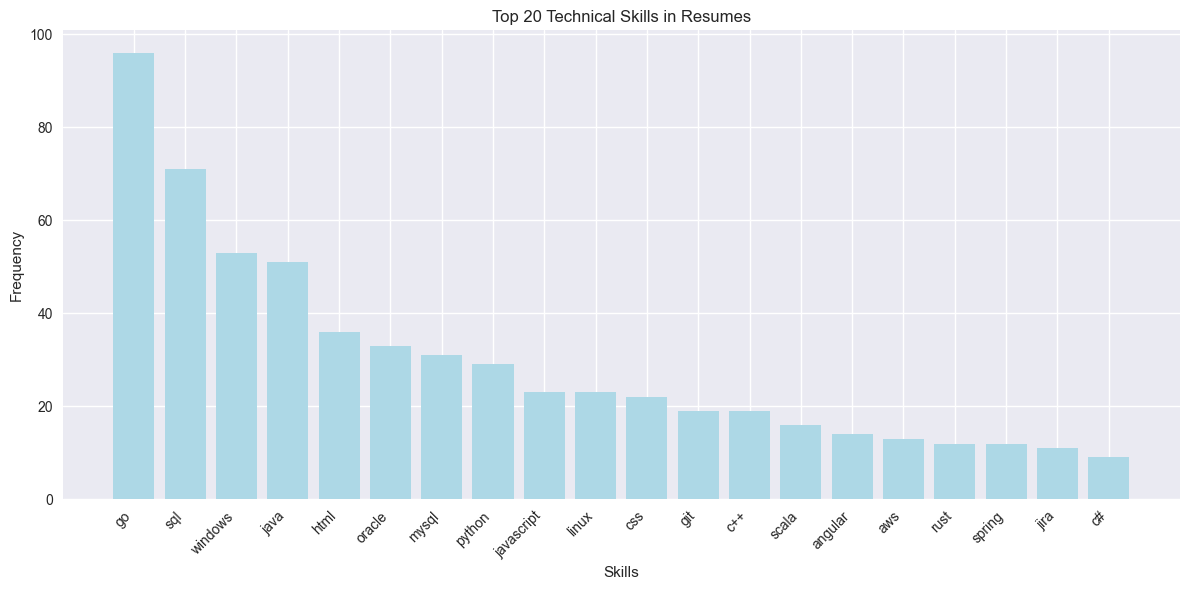

In [11]:
# Analyze most common skills
all_skills_found = []
for skills_list in df['skills']:
    all_skills_found.extend(skills_list)

skill_counts = Counter(all_skills_found)
top_skills = skill_counts.most_common(20)

print("Top 20 Skills:")
for skill, count in top_skills:
    print(f"{skill}: {count}")

# Visualize top skills
if top_skills:
    skills, counts = zip(*top_skills)
    plt.figure(figsize=(12, 6))
    plt.bar(skills, counts, color='lightblue')
    plt.title('Top 20 Technical Skills in Resumes')
    plt.xlabel('Skills')
    plt.ylabel('Frequency')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

## 8. Generate Word Clouds

Create word clouds for different job categories to visualize common terms.

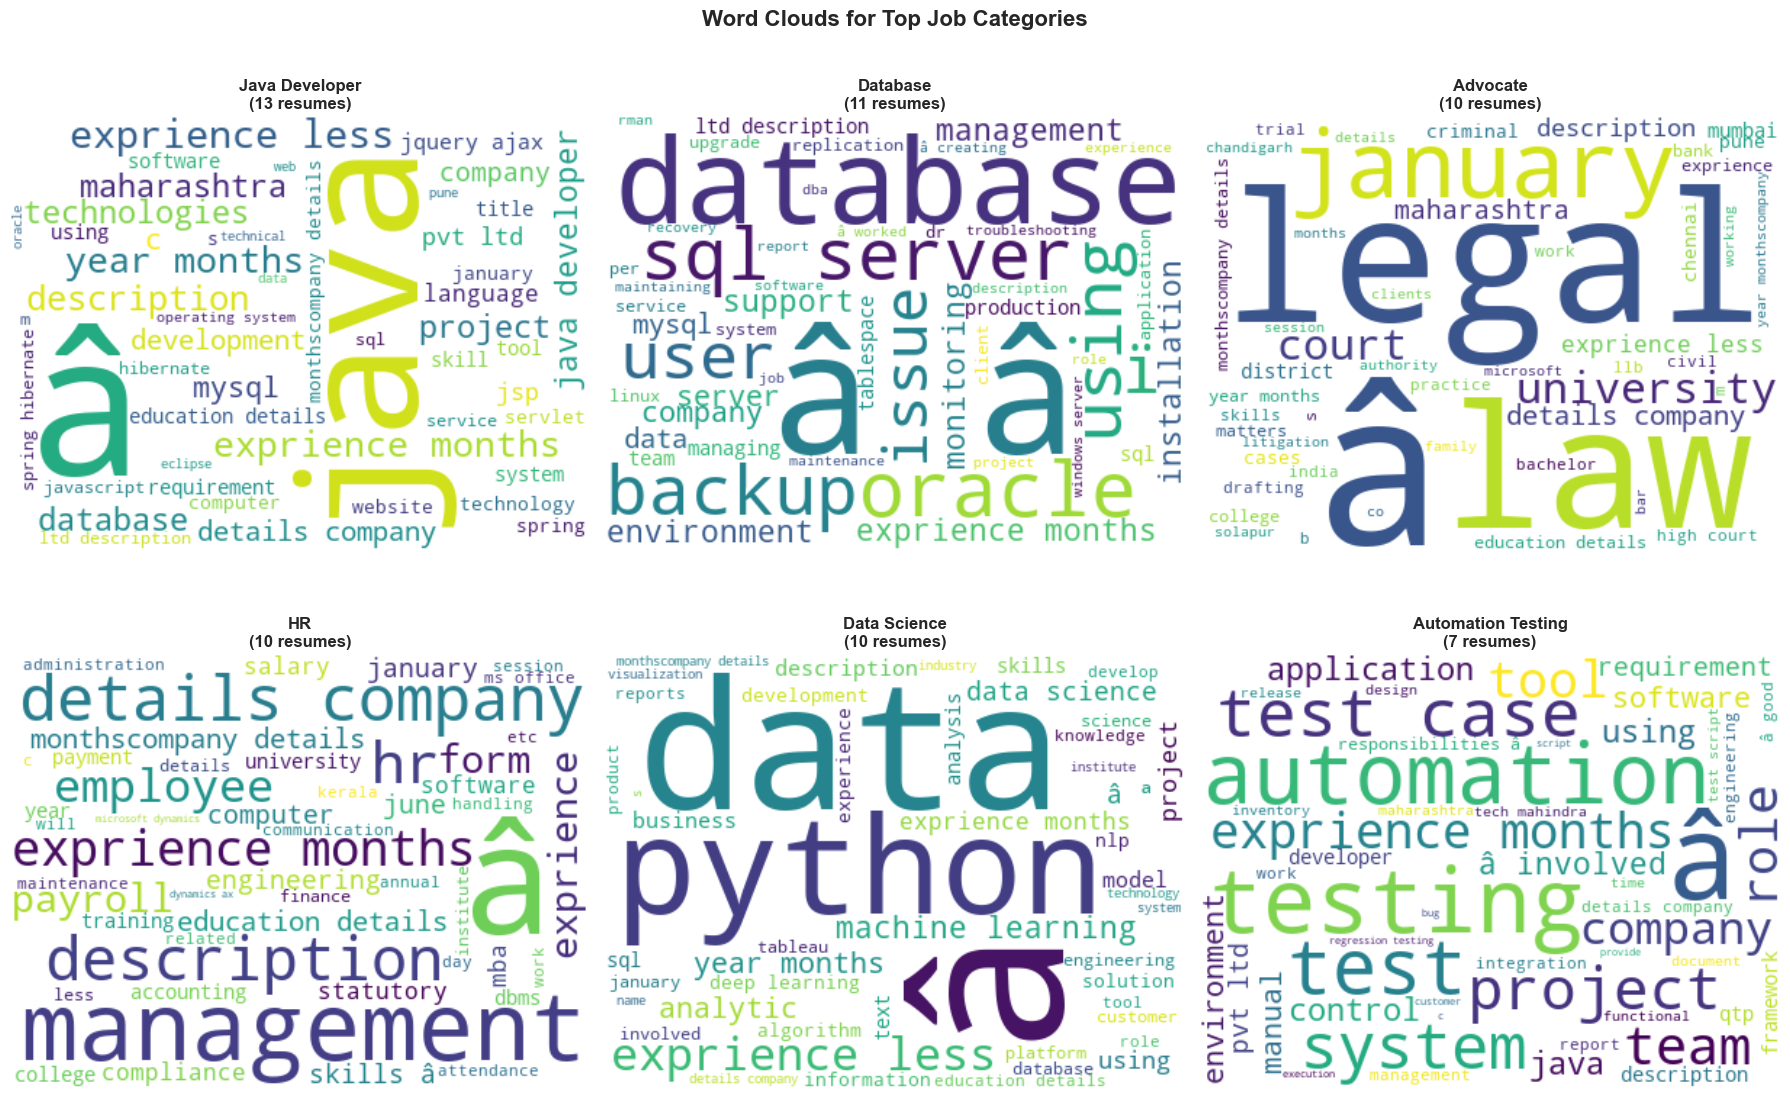

In [12]:
# Generate word clouds for top categories
top_categories = df['Category'].value_counts().head(6).index

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, category in enumerate(top_categories):
    # Get all text for this category
    category_text = ' '.join(df[df['Category'] == category]['Resume_cleaned'])
    
    # Generate word cloud
    wordcloud = WordCloud(
        width=400, 
        height=300, 
        background_color='white',
        max_words=50,
        colormap='viridis'
    ).generate(category_text)
    
    # Plot
    axes[i].imshow(wordcloud, interpolation='bilinear')
    axes[i].set_title(f'{category}\n({df[df["Category"] == category].shape[0]} resumes)', 
                     fontsize=12, fontweight='bold')
    axes[i].axis('off')

plt.suptitle('Word Clouds for Top Job Categories', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Encode Categorical Variables

Convert job categories to numerical format for machine learning.

In [13]:
# Encode categories
print("Encoding categories...")
label_encoder = LabelEncoder()
df['Category_encoded'] = label_encoder.fit_transform(df['Category'])

# Create category mapping
category_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print("\nCategory Mapping:")
for category, code in sorted(category_mapping.items()):
    print(f"{code}: {category}")

# Save label encoder for later use
import pickle
with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(label_encoder, f)
print("\n Label encoder saved!")

Encoding categories...

Category Mapping:
0: Advocate
1: Arts
2: Automation Testing
3: Blockchain
4: Business Analyst
5: Civil Engineer
6: Data Science
7: Database
8: DevOps Engineer
9: DotNet Developer
10: ETL Developer
11: Electrical Engineering
12: HR
13: Hadoop
14: Health and fitness
15: Java Developer
16: Mechanical Engineer
17: Network Security Engineer
18: Operations Manager
19: PMO
20: Python Developer
21: SAP Developer
22: Sales
23: Testing
24: Web Designing

 Label encoder saved!


## 10. Generate SBERT Embeddings

Create high-quality semantic embeddings using Sentence-BERT for ML models.

In [14]:
# Initialize SBERT model
print("Loading SBERT model...")
sbert_model = SentenceTransformer('all-MiniLM-L6-v2')

# Generate embeddings
print("Generating embeddings...")
embeddings = sbert_model.encode(
    df['Resume_cleaned'].tolist(), 
    show_progress_bar=True,
    batch_size=32
)

print(f"Embeddings generated!")
print(f"Shape: {embeddings.shape}")
print(f"Embedding dimension: {embeddings.shape[1]}")

# Save embeddings
np.save('embeddings.npy', embeddings)
print("Embeddings saved!")

Loading SBERT model...
Generating embeddings...


Batches: 100%|██████████| 6/6 [00:04<00:00,  1.34it/s]

Embeddings generated!
Shape: (166, 384)
Embedding dimension: 384
Embeddings saved!


## 11. Feature Selection and Analysis

Analyze embeddings and prepare features for machine learning.

Embedding Statistics:
Mean: -0.000808
Std: 0.051025
Min: -0.213075
Max: 0.204540


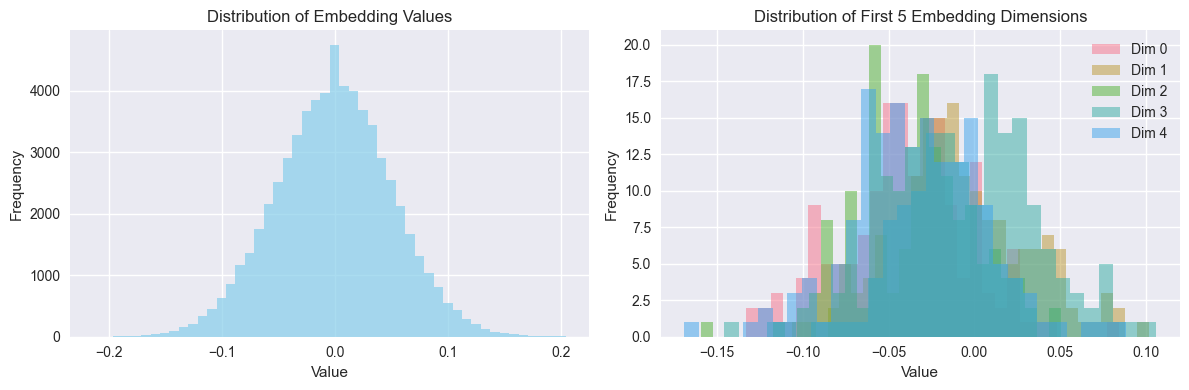

In [15]:
# Analyze embeddings
print("Embedding Statistics:")
print(f"Mean: {embeddings.mean():.6f}")
print(f"Std: {embeddings.std():.6f}")
print(f"Min: {embeddings.min():.6f}")
print(f"Max: {embeddings.max():.6f}")

# Visualize embedding distribution
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(embeddings.flatten(), bins=50, alpha=0.7, color='skyblue')
plt.title('Distribution of Embedding Values')
plt.xlabel('Value')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
# Plot first few dimensions
for i in range(min(5, embeddings.shape[1])):
    plt.hist(embeddings[:, i], bins=30, alpha=0.5, label=f'Dim {i}')
plt.title('Distribution of First 5 Embedding Dimensions')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.legend()

plt.tight_layout()
plt.show()

## 12. Split Data for Training and Testing

Divide the preprocessed data into training and testing sets.

In [16]:
# Prepare features and labels
X = embeddings
y = df['Category_encoded'].values

print(f"Data Shapes:")
print(f"Features (X): {X.shape}")
print(f"Labels (y): {y.shape}")
print(f"Unique classes: {len(np.unique(y))}")

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

print(f"\n Train/Test Split:")
print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"Split ratio: {X_test.shape[0]/X.shape[0]:.2%}")

# Check class distribution in splits
print(f"\n Class Distribution:")
train_counts = np.bincount(y_train)
test_counts = np.bincount(y_test)
print(f"Training classes: {len(train_counts)} categories")
print(f"Test classes: {len(test_counts)} categories")

Data Shapes:
Features (X): (166, 384)
Labels (y): (166,)
Unique classes: 25

 Train/Test Split:
Training set: 132 samples
Test set: 34 samples
Split ratio: 20.48%

 Class Distribution:
Training classes: 25 categories
Test classes: 25 categories


In [17]:
# Save preprocessed data
print("Saving preprocessed data...")

# Save splits
np.save('X_train.npy', X_train)
np.save('X_test.npy', X_test)
np.save('y_train.npy', y_train)
np.save('y_test.npy', y_test)

# Save processed dataframe
df_processed = df[['Resume', 'Resume_cleaned', 'Category', 'Category_encoded', 'skills', 'skill_count']]
df_processed.to_csv('processed_resumes.csv', index=False)

print("All data saved successfully!")
print("\n Files created:")
print("- embeddings.npy")
print("- label_encoder.pkl")
print("- X_train.npy, X_test.npy")
print("- y_train.npy, y_test.npy")
print("- processed_resumes.csv")

Saving preprocessed data...
All data saved successfully!

 Files created:
- embeddings.npy
- label_encoder.pkl
- X_train.npy, X_test.npy
- y_train.npy, y_test.npy
- processed_resumes.csv


## 13. Summary and Next Steps

Summary of preprocessing results and recommendations for model training.

In [18]:
# Final summary
print("Data Preprocessing Complete!")
print(f"Final Dataset:")
print(f"- Total resumes: {len(df)}")
print(f"- Job categories: {df['Category'].nunique()}")
print(f"- Average text length: {df['Resume_cleaned'].str.len().mean():.0f} characters")
print(f"- Average skills per resume: {df['skill_count'].mean():.1f}")
print(f"- Embedding dimensions: {embeddings.shape[1]}")

print(f"\n Ready for Model Training:")
print(f"- Training samples: {X_train.shape[0]}")
print(f"- Test samples: {X_test.shape[0]}")
print(f"- Feature dimensions: {X_train.shape[1]}")
print(f"- Classes: {len(np.unique(y))}")

print(f"\n Recommended Next Steps:")
print("1. Train multiple ML models (RandomForest, XGBoost, SVM)")
print("2. Perform hyperparameter tuning")
print("3. Evaluate models using cross-validation")
print("4. Select best performing model")
print("5. Create prediction pipeline")

print(f"\n All preprocessed data saved and ready for ML training!")

Data Preprocessing Complete!
Final Dataset:
- Total resumes: 166
- Job categories: 25
- Average text length: 2827 characters
- Average skills per resume: 4.1
- Embedding dimensions: 384

 Ready for Model Training:
- Training samples: 132
- Test samples: 34
- Feature dimensions: 384
- Classes: 25

 Recommended Next Steps:
1. Train multiple ML models (RandomForest, XGBoost, SVM)
2. Perform hyperparameter tuning
3. Evaluate models using cross-validation
4. Select best performing model
5. Create prediction pipeline

 All preprocessed data saved and ready for ML training!


In [19]:
# Data Preprocessing: Load and clean resume data
import pandas as pd
import re

def preprocess_text(text):
    text = re.sub(r'\s+', ' ', text.strip())
    text = re.sub(r'[^\w\s\+\#\-\.]', ' ', text)
    return text.lower()

# Load dataset
csv_path = 'resume_dataset.csv'
df = pd.read_csv(csv_path)
df['Resume'] = df['Resume'].apply(preprocess_text)
print(f"Loaded {len(df)} resumes with {df['Category'].nunique()} categories")
df.head()

Loaded 169 resumes with 25 categories


,Category,Resume
0,Data Science,skills programming languages python pandas numpy scipy scikit-learn matplotlib sql ja...
1,Data Science,education details may 2013 to may 2017 b.e uit-rgpvdata scientistdata scientist - matelabsskill ...
2,Data Science,areas of interest deep learning control system design programming in-python electric machiner...
3,Data Science,skills â r â python â sap hana â tableau â sap hana sql â sap hana pal â ms sql â ...
4,Data Science,education details mca ymcaust faridabad haryanadata science internshipskill details data struc...


# 🤖 Machine Learning Model Training & Evaluation

Now that we have preprocessed data and embeddings, let's train our resume classifier model.

In [20]:
# Train Random Forest Model
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pickle

# Initialize and train the model
print("Training Random Forest classifier...")
model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

print("Model training completed!")
print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")
print(f"Number of features: {X_train.shape[1]}")
print(f"Number of categories: {len(label_encoder.classes_)}")

Training Random Forest classifier...
Model training completed!
Training set size: 132
Test set size: 34
Number of features: 384
Number of categories: 25


In [21]:
# Model Evaluation
print("Evaluating Model Performance...")

# Predictions on test set
y_pred = model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_pred)

# Predictions on training set (to check for overfitting)
y_train_pred = model.predict(X_train)
train_accuracy = accuracy_score(y_train, y_train_pred)

print(f"Training Accuracy: {train_accuracy:.3f}")
print(f"Test Accuracy: {test_accuracy:.3f}")
print(f"Accuracy Difference: {abs(train_accuracy - test_accuracy):.3f}")

if abs(train_accuracy - test_accuracy) > 0.1:
    print("Warning: Large accuracy difference may indicate overfitting")
else:
    print(" Good model generalization")

print("\n Detailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

Evaluating Model Performance...
Training Accuracy: 1.000
Test Accuracy: 0.471
Accuracy Difference: 0.529

 Detailed Classification Report:
                           precision    recall  f1-score   support

                 Advocate       0.67      1.00      0.80         2
                     Arts       0.00      0.00      0.00         1
       Automation Testing       0.50      1.00      0.67         1
               Blockchain       0.00      0.00      0.00         1
         Business Analyst       0.20      1.00      0.33         1
           Civil Engineer       0.00      0.00      0.00         1
             Data Science       0.50      0.50      0.50         2
                 Database       0.67      1.00      0.80         2
          DevOps Engineer       0.00      0.00      0.00         1
         DotNet Developer       1.00      0.50      0.67         2
            ETL Developer       0.00      0.00      0.00         1
   Electrical Engineering       0.50      1.00      0.67

In [22]:
# Save Model and Components
print(" Saving trained model and components...")

# Save the trained model
with open('resume_model.pkl', 'wb') as f:
    pickle.dump(model, f)

# Save the label encoder
with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(label_encoder, f)

# Save embeddings and splits for future use
np.save('embeddings.npy', embeddings)
np.save('X_train.npy', X_train)
np.save('X_test.npy', X_test)
np.save('y_train.npy', y_train)
np.save('y_test.npy', y_test)

print(" All components saved successfully!")
print(" Saved files:")
print("   - resume_model.pkl (trained Random Forest)")
print("   - label_encoder.pkl (category encoder)")
print("   - embeddings.npy (all resume embeddings)")
print("   - X_train.npy, X_test.npy (feature splits)")
print("   - y_train.npy, y_test.npy (label splits)")

 Saving trained model and components...
 All components saved successfully!
 Saved files:
   - resume_model.pkl (trained Random Forest)
   - label_encoder.pkl (category encoder)
   - embeddings.npy (all resume embeddings)
   - X_train.npy, X_test.npy (feature splits)
   - y_train.npy, y_test.npy (label splits)


# 🔮 Resume Classification Prediction

Test the trained model with new resume samples.

In [23]:
# Resume Prediction Function
def predict_resume_category(resume_text, model, encoder, sbert_model):
    """
    Predict the category of a resume text
    """
    # Preprocess text (same as training data)
    clean_text = re.sub(r'\s+', ' ', resume_text.strip().lower())
    clean_text = re.sub(r'[^\w\s\+\#\-\.]', ' ', clean_text)
    
    # Generate embedding
    embedding = sbert_model.encode([clean_text])
    
    # Predict
    prediction = model.predict(embedding)[0]
    probabilities = model.predict_proba(embedding)[0]
    
    # Get category name and confidence
    category = encoder.inverse_transform([prediction])[0]
    confidence = max(probabilities)
    
    return {
        'category': category,
        'confidence': confidence,
        'all_probabilities': dict(zip(encoder.classes_, probabilities))
    }

# Test with sample resumes
sample_resumes = [
    """
    Software Engineer with 5 years experience in Python, Django, and React.
    Built scalable web applications and RESTful APIs. Experience with AWS,
    Docker, and CI/CD pipelines. Strong background in algorithms and data structures.
    """,
    """
    Marketing Manager with expertise in digital marketing, SEO, and social media.
    Led campaigns that increased brand awareness by 40%. Experience with Google Analytics,
    Facebook Ads, and content marketing strategies.
    """,
    """
    Data Scientist with PhD in Statistics. Expert in machine learning, deep learning,
    and statistical analysis. Proficient in Python, R, SQL, and TensorFlow.
    Published research in top-tier journals.
    """
]

print(" Testing Resume Classification:")

for i, resume in enumerate(sample_resumes, 1):
    result = predict_resume_category(resume, model, label_encoder, sbert_model)
    print(f"\n Sample Resume {i}:")
    print(f" Predicted Category: {result['category']}")
    print(f" Confidence: {result['confidence']:.3f}")
    print(f"Top 3 Probabilities:")
    sorted_probs = sorted(result['all_probabilities'].items(), key=lambda x: x[1], reverse=True)[:3]
    for cat, prob in sorted_probs:
        print(f"   {cat}: {prob:.3f}")


 Testing Resume Classification:

 Sample Resume 1:
 Predicted Category: Data Science
 Confidence: 0.140
Top 3 Probabilities:
   Data Science: 0.140
   Python Developer: 0.130
   HR: 0.100

 Sample Resume 2:
 Predicted Category: HR
 Confidence: 0.150
Top 3 Probabilities:
   HR: 0.150
   Data Science: 0.090
   Sales: 0.080

 Sample Resume 3:
 Predicted Category: HR
 Confidence: 0.110
Top 3 Probabilities:
   HR: 0.110
   Data Science: 0.100
   Python Developer: 0.100


In [24]:
# Load Saved Models (for future use)
def load_trained_model():
    """
    Load all trained components from saved files
    """
    print("Loading saved model components...")
    
    # Load model
    with open('resume_model.pkl', 'rb') as f:
        loaded_model = pickle.load(f)
    
    # Load label encoder
    with open('label_encoder.pkl', 'rb') as f:
        loaded_encoder = pickle.load(f)
    
    # Load SBERT model
    loaded_sbert = SentenceTransformer('all-MiniLM-L6-v2')
    
    print("All components loaded successfully!")
    return loaded_model, loaded_encoder, loaded_sbert

# Example usage (uncomment when needed):
# loaded_model, loaded_encoder, loaded_sbert = load_trained_model()
# 
# # Test with new resume
# new_resume = "Your resume text here..."
# prediction = predict_resume_category(new_resume, loaded_model, loaded_encoder, loaded_sbert)
# print(f"Category: {prediction['category']}, Confidence: {prediction['confidence']:.3f}")

print("Complete ML Pipeline Ready!")
print("Data preprocessing completed")
print("Feature extraction (embeddings) completed") 
print("Model training completed")
print("Model evaluation completed")
print("Model saving completed")
print("Prediction function ready")
print("Model loading function ready")

Complete ML Pipeline Ready!
Data preprocessing completed
Feature extraction (embeddings) completed
Model training completed
Model evaluation completed
Model saving completed
Prediction function ready
Model loading function ready
